In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

Effekt genereret af fotodioden:
$$
P_{\text{S1223}} \approx P_{LED} \times \text{Transmission} \times \text{Lystab}
$$

Strømmen på fotodioden beskrives som:
$$
I_{\text{S1223}} = R(\lambda) \times P_{\text{S1223}}
$$
Den er afhængig af fotodiodens fotosensitivitet, som er afhængig af bølgelængden, og effekten skabt af fotodioden ved den bølgelængde.

Udgangspændingen fra TIA er:
$$
V_{out} \approx I_{\text{S1223}} \times R_f
$$  
Udgangsspændingen kan altså beskrives som produktet mellem en feedback modstand og strømmen genereret af fotodioden.

------------------

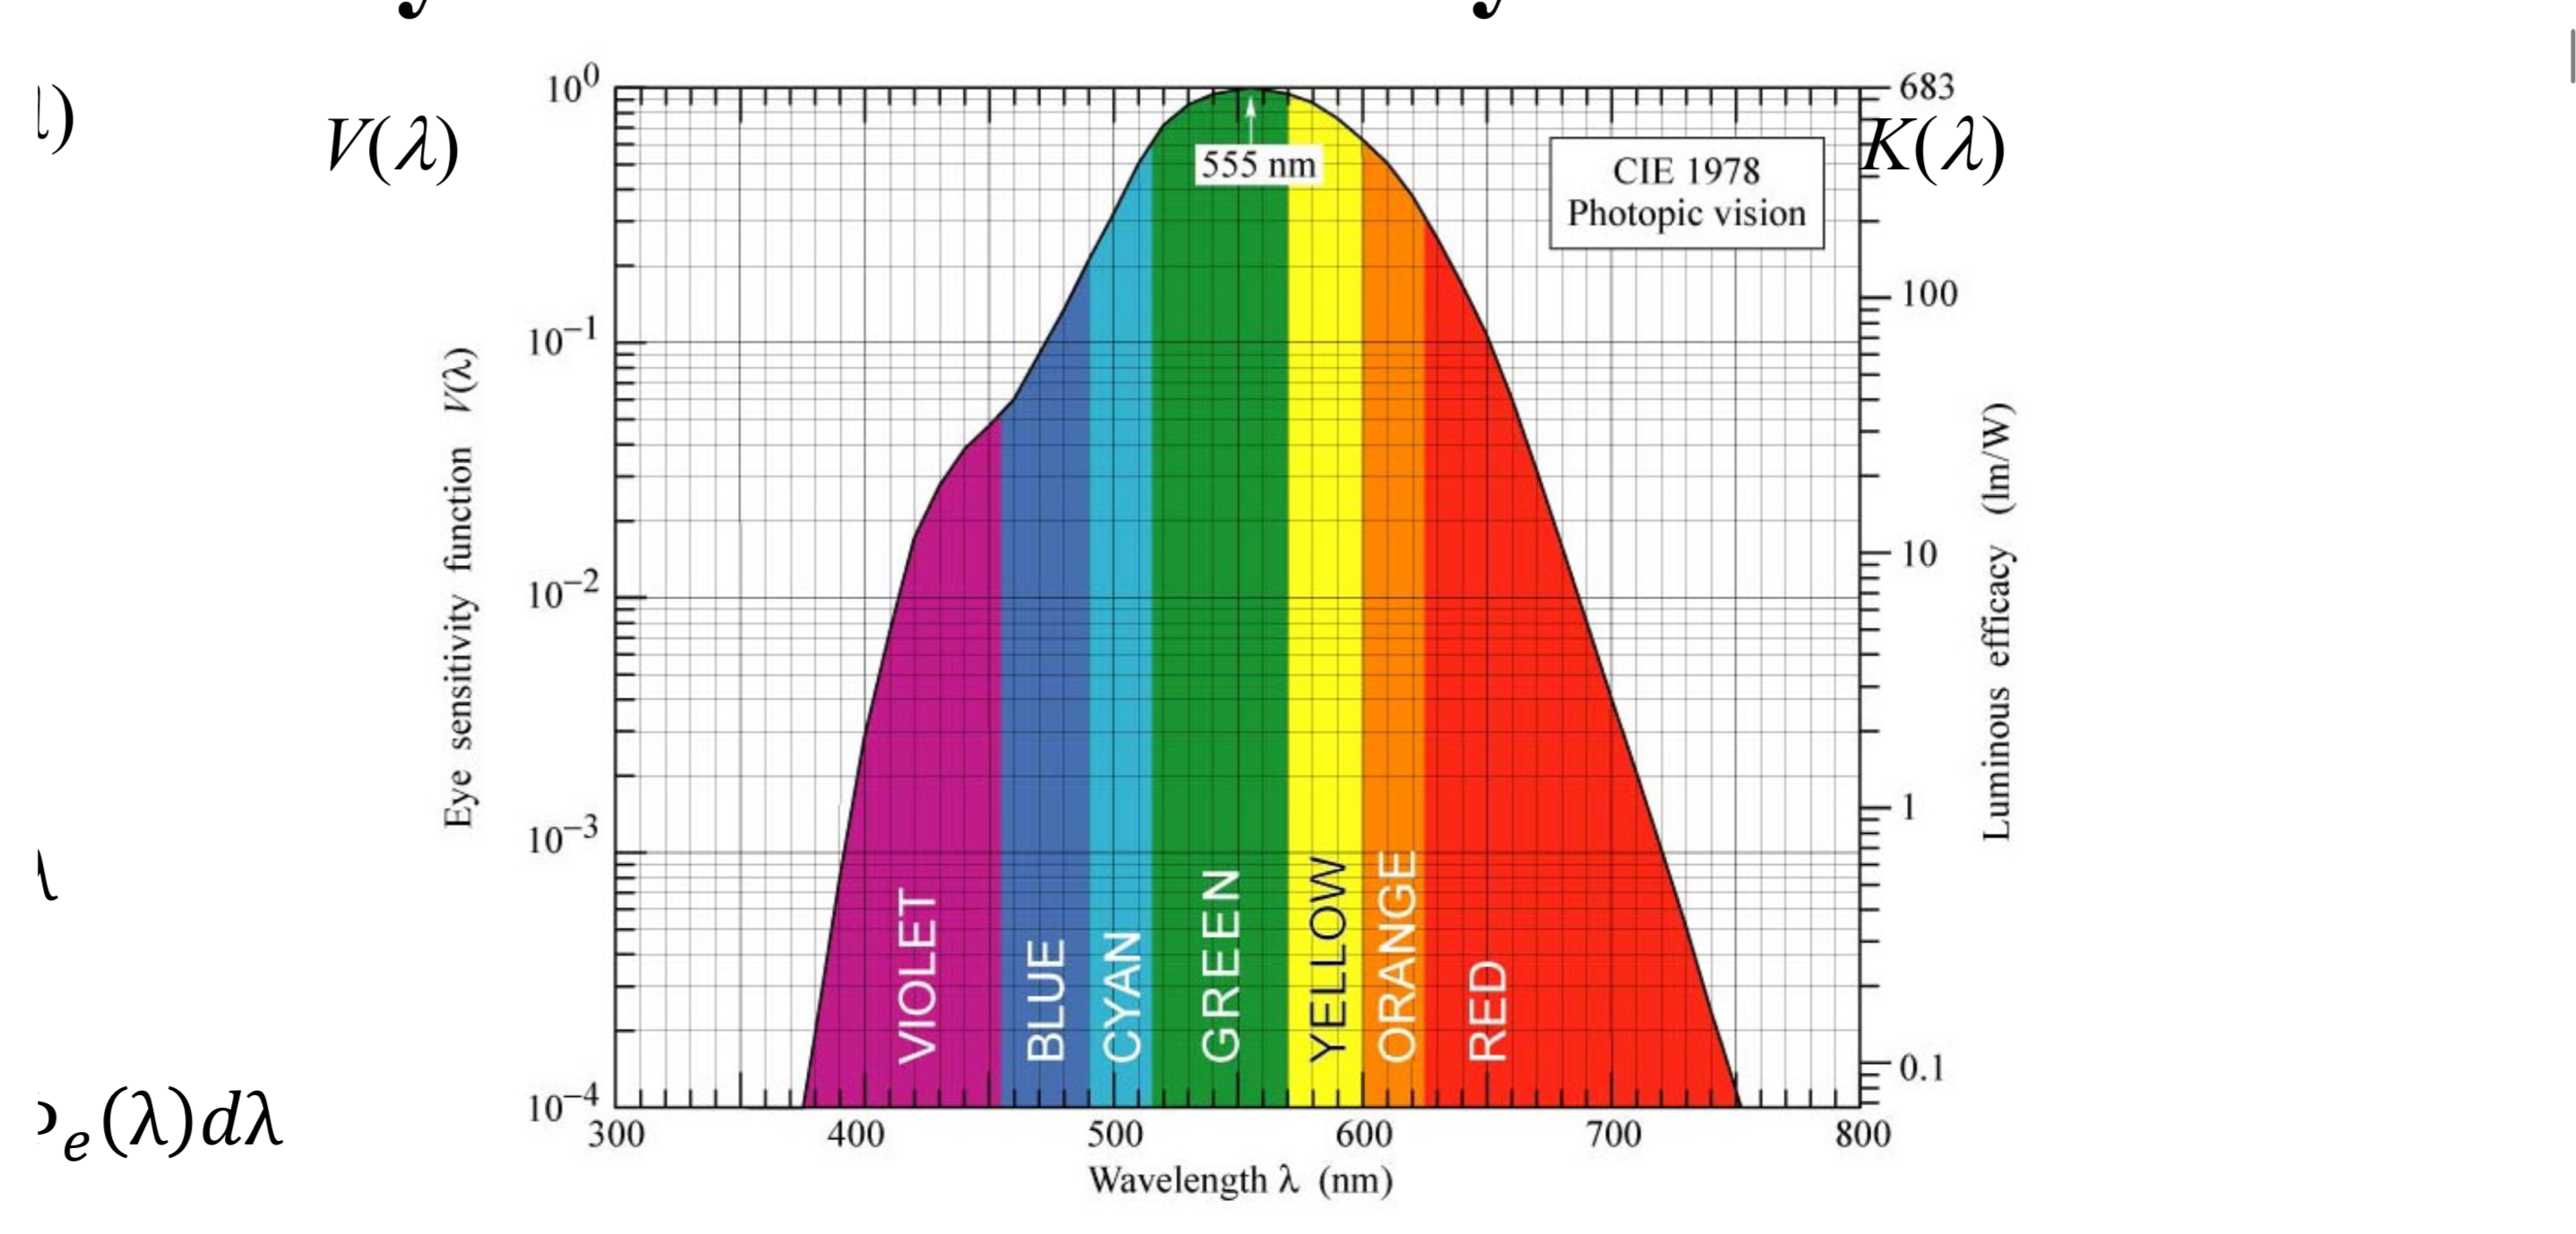

In [2]:
# 590nm - isosbestisk
# Luminous_intensity_590 = 4.4 # Candela ved 100 mA
# Eye_sensitivity_590 = 0.7
# Radiant_intensity_590 = round(Luminous_intensity_590 / (683 * Eye_sensitivity_590), 2) # W/Str, radiant intensitet

# 800nm - isosbestisk
Radiant_intensity_800 = 0.06 # W/Str, radiant intensitet, ved 70 mA, cirka..

# 660nm
Luminous_intensity_660 = 1.95 # Candela ved 30 mA
Eye_sensitivity_660 = 0.05 # Aflæst fra graf ovenover
Radiant_intensity_660 = round(Luminous_intensity_660 / (683 * Eye_sensitivity_660), 2) # W/Str, radiant intensitet


# 930nm
Radiant_intensity_930 = 0.06 # W/Str, radiant intensitet, ved 35 mA

# print(f"Radiant intensitet for isosbestisk-LED er {Radiant_intensity_590:.2g} W/str \n")
print(f"Radiant intensitet for isosbestisk-LED er {Radiant_intensity_800:.2g} W/str \n")
print(f"Radiant intensitet for IR-LED er {Radiant_intensity_660:.2g} W/str \n")
print(f"Radiant intensitet for rød-LED er {Radiant_intensity_930:.2g} W/str \n {"-"*80}")
print(f"IR radiant intensitet er {Radiant_intensity_930/Radiant_intensity_660:.2g} gange større end rød LED radiant intensitet")

Radiant intensitet for isosbestisk-LED er 0.06 W/str 

Radiant intensitet for IR-LED er 0.06 W/str 

Radiant intensitet for rød-LED er 0.06 W/str 
 --------------------------------------------------------------------------------
IR radiant intensitet er 1 gange større end rød LED radiant intensitet


In [3]:
# Pulsen i fingeren kan approksimeres som en sinus bølge
fs = 1000                           # Hz sample rate
t = np.arange(0, 5, 1/fs)           # 5 sekunder
f_puls = 72/60                      # Hz = 72 BPM / 60


# Fotodiode parametre
S1223_areal = 0.0024 * 0.0028       # I meter. Kilde: S1223 Datasheet
r = 0.012                           # Afstand fra LED til PD, altså pegefingerens tykkelse hos mænd
Steradian_S1223 = S1223_areal/r**2  # Rumvinkel fra LED til PD


# Parametre
T_væv = 0.3                         # Bølgelængde uafhængig (knogle,  fedt, hud)
SpO2 = 0.98                         # Eksempelvis patient med en SpO2 på 98%
c_Hb = 0.010                        # 10 mmol/L er gennemsnitligt for mænd


# Tykkelsen af fingeren, statisk og som funktion af puls
d_blod_DC = 0.1                             # cm, optisk vejlængde gennem arterielt blod
d_blod_AC = d_blod_DC * 0.02                # m, pulsvariation (~2% af DC)
d_blod_t = d_blod_DC + d_blod_AC * np.sin(2 * np.pi * f_puls * t)


# $\varepsilon$: Extinction coefficient
eps_660 = SpO2 * 350 + (1 - SpO2) * 3800
eps_800 = SpO2 * 850 + (1 - SpO2) * 850
eps_930 = SpO2 * 800 + (1 - SpO2) * 1300

### Beer Lambert lov - Fysik version
$$
I = I_0 \cdot e^{-\mu \cdot d}
$$  

In [4]:
# Absorptionskoefficient
mu_660 = eps_660 * c_Hb * np.log(10)
mu_800 = eps_800 * c_Hb * np.log(10)
mu_930 = eps_930 * c_Hb * np.log(10)

# Intensitet er lig med statisk intensitet fra væv, og den varierende puls fra blod
T_finger_660 = T_væv * np.exp(-mu_660 * d_blod_t)
T_finger_800 = T_væv * np.exp(-mu_800 * d_blod_t)
T_finger_930 = T_væv * np.exp(-mu_930 * d_blod_t)

In [5]:
# 3D print geometrien er ikke perfekt, og vil tage noget af lyset, derfor gættes en faktor 0.7 som fjerner 30% af effekten
Transmission_LED_3D_print_geom = 0.7

# Effekt fra begge LEDer
P_660 = Radiant_intensity_660 * Steradian_S1223 * Transmission_LED_3D_print_geom * T_finger_660
P_800 = Radiant_intensity_800 * Steradian_S1223 * Transmission_LED_3D_print_geom * T_finger_800
P_930 = Radiant_intensity_930 * Steradian_S1223 * Transmission_LED_3D_print_geom * T_finger_930

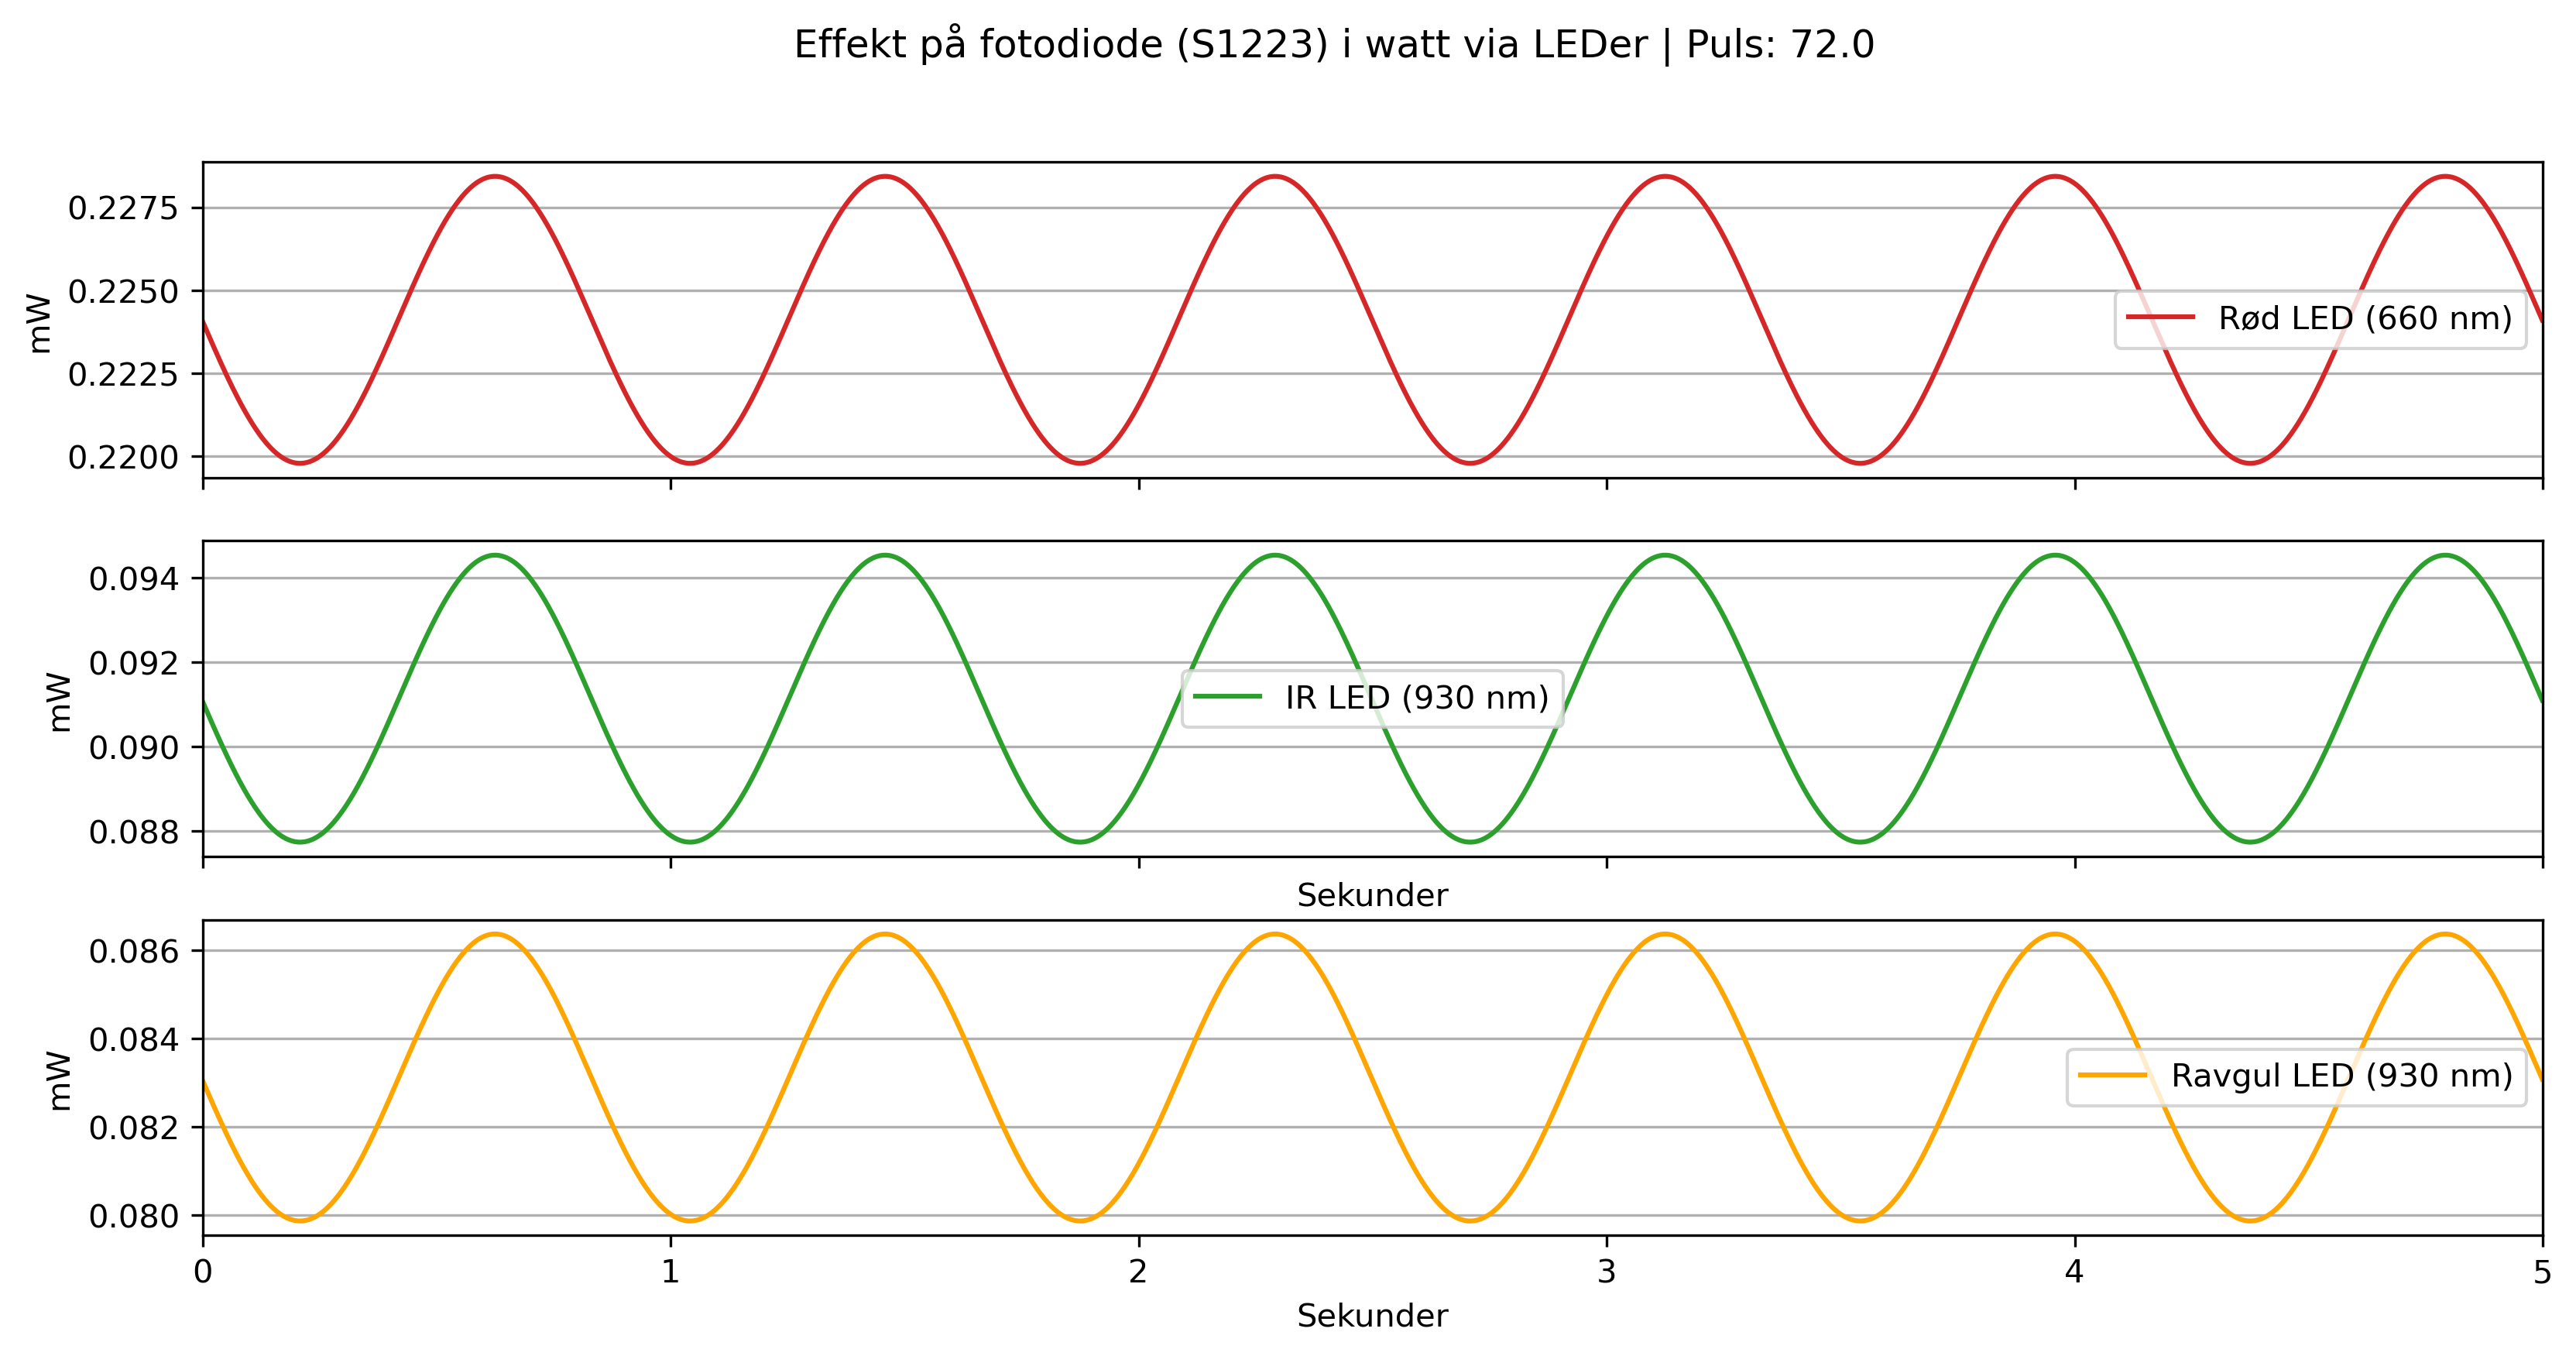

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(13, 6), dpi=300, sharex=True)
fig.suptitle(f"Effekt på fotodiode (S1223) i watt via LEDer | Puls: {f_puls*60}")

ax[0].plot(t, P_660*1000, label="Rød LED (660 nm)", color="tab:red")
ax[0].set_xlim(0, 5)
ax[0].set_ylabel("mW")
ax[0].legend()
ax[0].grid(axis="y")

ax[1].plot(t, P_930*1000, label="IR LED (930 nm)", color="tab:green")
ax[1].set_xlim(0, 5)
ax[1].set_ylabel("mW")
ax[1].set_xlabel("Sekunder")
ax[1].legend()
ax[1].grid(axis="y")

ax[2].plot(t, P_800*1000, label="Ravgul LED (930 nm)", color="orange")
ax[2].set_xlim(0, 5)
ax[2].set_ylabel("mW")
ax[2].set_xlabel("Sekunder")
ax[2].legend()
ax[2].grid(axis="y")

plt.show()

In [7]:
Fotosensitivitet_660 = 0.46  # A/W. Kilde: Datsheet
Fotosensitivitet_800 = 0.525 # A/W. Kilde: Datsheet
Fotosensitivitet_930 = 0.6   # A/W. Kilde: Datsheet

# Strøm fra begge fotodioder
I_660 = Fotosensitivitet_660 * P_660
I_800 = Fotosensitivitet_800 * P_800
I_930 = Fotosensitivitet_930 * P_930

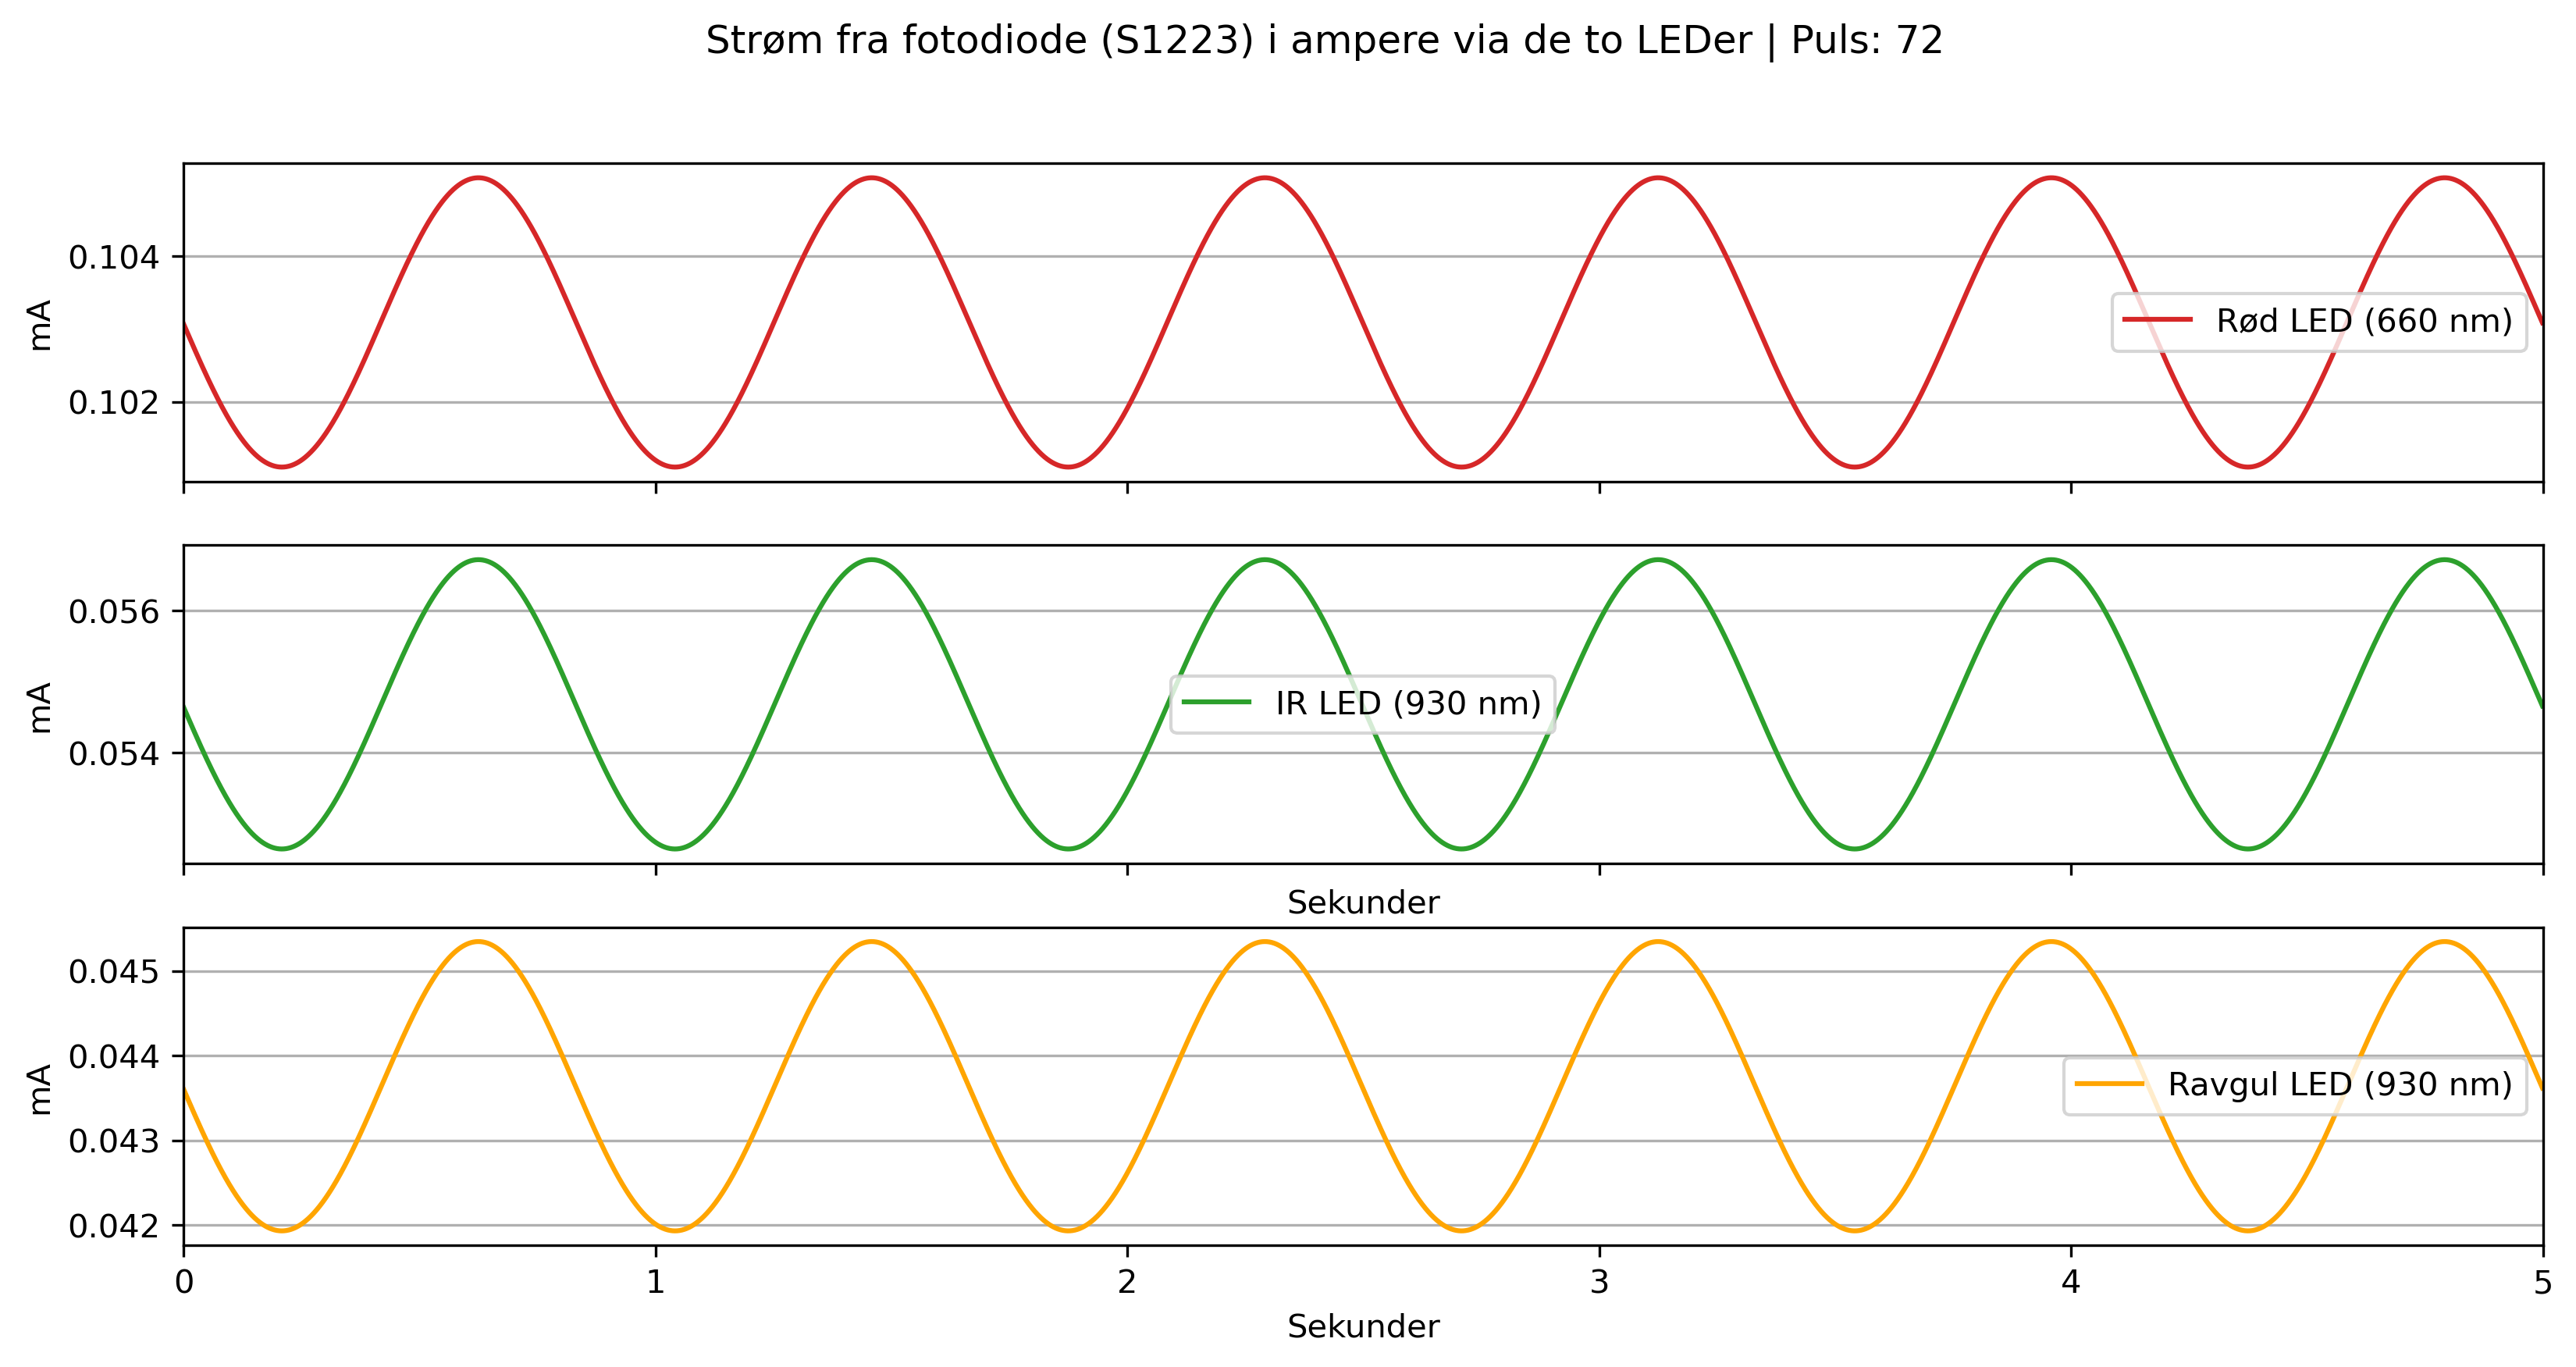

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(13, 6), dpi=300, sharex=True)
fig.suptitle(f"Strøm fra fotodiode (S1223) i ampere via de to LEDer | Puls: {f_puls*60:.0f}")

ax[0].plot(t, I_660*1000, label="Rød LED (660 nm)", color="tab:red")
ax[0].set_xlim(1, 5)
ax[0].set_ylabel("mA")
ax[0].legend()
ax[0].grid(axis="y")

ax[1].plot(t, I_930*1000, label="IR LED (930 nm)", color="tab:green")
ax[1].set_xlim(0, 5)
ax[1].set_ylabel("mA")
ax[1].set_xlabel("Sekunder")
ax[1].legend()
ax[1].grid(axis="y")

ax[2].plot(t, I_800*1000, label="Ravgul LED (930 nm)", color="orange")
ax[2].set_xlim(0, 5)
ax[2].set_ylabel("mA")
ax[2].set_xlabel("Sekunder")
ax[2].legend()
ax[2].grid(axis="y")

plt.show()

In [9]:
# Feedback modstanden R_f i TIA
R_feedback = 100_000

# 50 Hz interferens
noise_amplitude = 0.05 # Et gæt
hvid_støj = 0.005 * np.random.randn(len(t))  # 5 mV RMS

interferens_50hz = noise_amplitude * np.sin(2 * np.pi * 50 * t) + hvid_støj

# Ufiltreret spænding
V_TIA_930 = Fotosensitivitet_930 * P_930 * R_feedback + interferens_50hz
V_TIA_800 = Fotosensitivitet_800 * P_800 * R_feedback + interferens_50hz
V_TIA_660 = Fotosensitivitet_660 * P_660 * R_feedback + interferens_50hz

# Sallen-Key HP 0.5 Hz (fjerner DC)
HP_fc = 0.5
b_hp, a_hp = butter(2, HP_fc, btype="high", fs=fs)
V_hp_930 = lfilter(b_hp, a_hp, V_TIA_930)
V_hp_800 = lfilter(b_hp, a_hp, V_TIA_800)
V_hp_660 = lfilter(b_hp, a_hp, V_TIA_660)

# Sallen-Key LP 3 Hz (fjerner 50 Hz støj)
LP_fc = 3
b_lp, a_lp = butter(2, LP_fc, btype="low", fs=fs)
V_filt_930 = lfilter(b_lp, a_lp, V_hp_930)
V_filt_800 = lfilter(b_lp, a_lp, V_hp_800)
V_filt_660 = lfilter(b_lp, a_lp, V_hp_660)

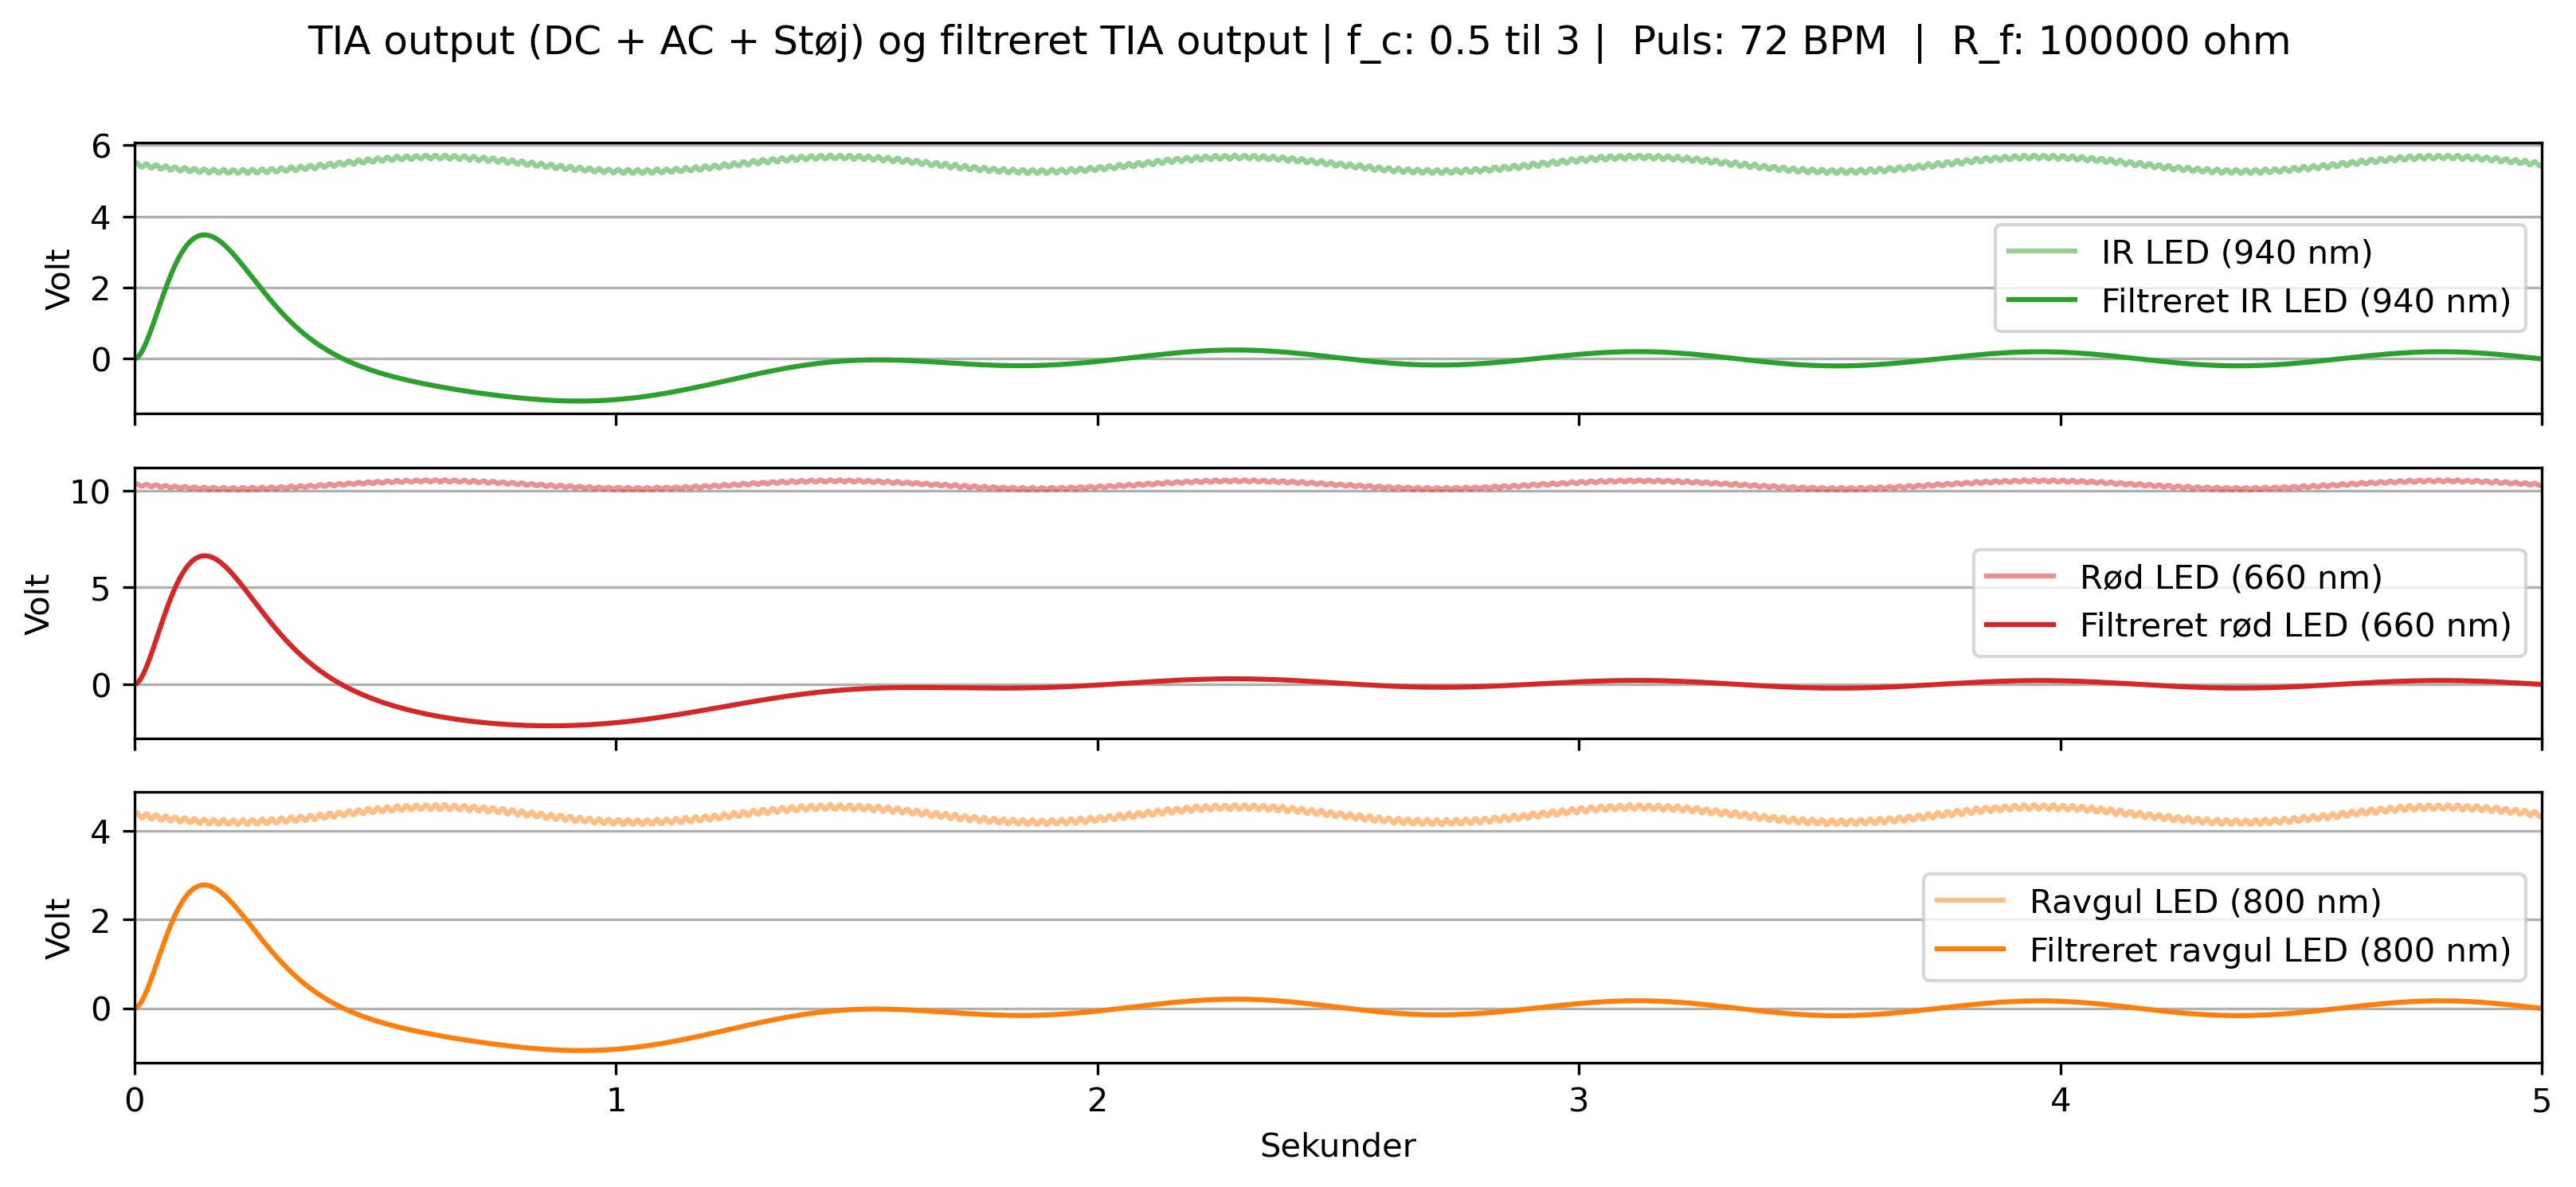

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(13, 5), dpi=300, sharex=True)
fig.suptitle(f"TIA output (DC + AC + Støj) og filtreret TIA output | f_c: {HP_fc} til {LP_fc} |  Puls: {f_puls*60:.0f} BPM  |  R_f: {R_feedback} ohm")

ax[0].plot(t, V_TIA_930, label="IR LED (940 nm)", color="tab:green", alpha=0.5)
ax[0].plot(t, V_filt_930, label="Filtreret IR LED (940 nm)", color="tab:green")
ax[0].set_xlim(1, 5)
ax[0].set_ylabel("Volt")
ax[0].legend()
ax[0].grid(axis="y")

ax[1].plot(t, V_TIA_660, label="Rød LED (660 nm)", color="tab:red", alpha=0.5)
ax[1].plot(t, V_filt_660, label="Filtreret rød LED (660 nm)", color="tab:red")
ax[1].set_xlim(0, 5)
ax[1].set_ylabel("Volt")
ax[1].legend()
ax[1].grid(axis="y")

ax[2].plot(t, V_TIA_800, label="Ravgul LED (800 nm)", color="tab:orange", alpha = 0.5)
ax[2].plot(t, V_filt_800, label="Filtreret ravgul LED (800 nm)", color="tab:orange")
ax[2].set_xlim(0, 5)
ax[2].set_ylabel("Volt")
ax[2].set_xlabel("Sekunder")
ax[2].legend()
ax[2].grid(axis="y")

plt.show()

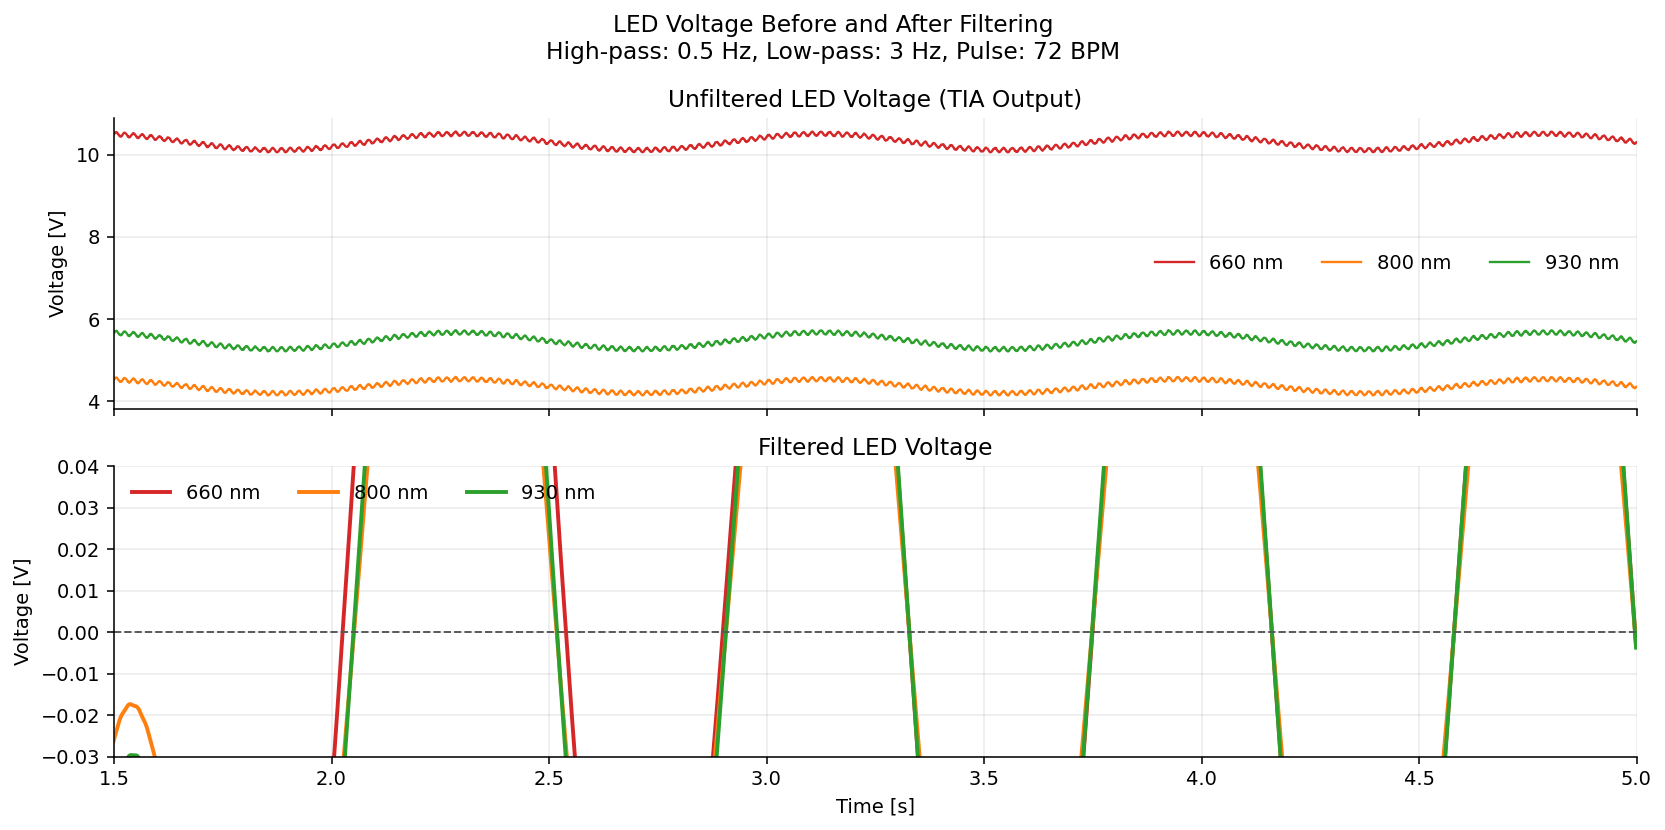

In [11]:
# Plot only after filter startup transient
plot_start = 1.0
mask = t >= plot_start

# Smaller DPI renders faster in notebooks
fig, ax = plt.subplots(2, 1, figsize=(12, 6), dpi=140, sharex=True)

fig.suptitle(
    f"LED Voltage Before and After Filtering\n"
    f"High-pass: {HP_fc} Hz, Low-pass: {LP_fc} Hz, Pulse: {f_puls*60:.0f} BPM"
)

# Unfiltered signals
ax[0].plot(t[mask], V_TIA_660[mask], label="660 nm", color="tab:red", linewidth=1.2)
ax[0].plot(t[mask], V_TIA_800[mask], label="800 nm", color="tab:orange", linewidth=1.2)
ax[0].plot(t[mask], V_TIA_930[mask], label="930 nm", color="tab:green", linewidth=1.2)
ax[0].set_title("Unfiltered LED Voltage (TIA Output)")
ax[0].set_ylabel("Voltage [V]")
ax[0].grid(True, alpha=0.25)
ax[0].legend(frameon=False, ncol=3)

# Filtered signals
ax[1].plot(t[mask], V_filt_660[mask], label="660 nm", color="tab:red", linewidth=2.0)
ax[1].plot(t[mask], V_filt_800[mask], label="800 nm", color="tab:orange", linewidth=2.0)
ax[1].plot(t[mask], V_filt_930[mask], label="930 nm", color="tab:green", linewidth=2.0)
ax[1].axhline(0, color="0.35", linestyle="--", linewidth=1)
ax[1].set_title("Filtered LED Voltage")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Voltage [V]")
ax[1].set_xlim(1.5, 5)
ax[1].set_ylim(-0.03, 0.04)
ax[1].grid(True, alpha=0.25)
ax[1].legend(frameon=False, ncol=3)

for axis in ax:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [12]:
# De to modstande i gain kredsløbet
Ra = 20_000         # ohm
Rb = 1000           # ohm
gain = 1 + Ra/Rb    # non-inverting gain

V_forstærket_930 = gain * V_filt_930
V_forstærket_800 = gain * V_filt_800
V_forstærket_660 = gain * V_filt_660

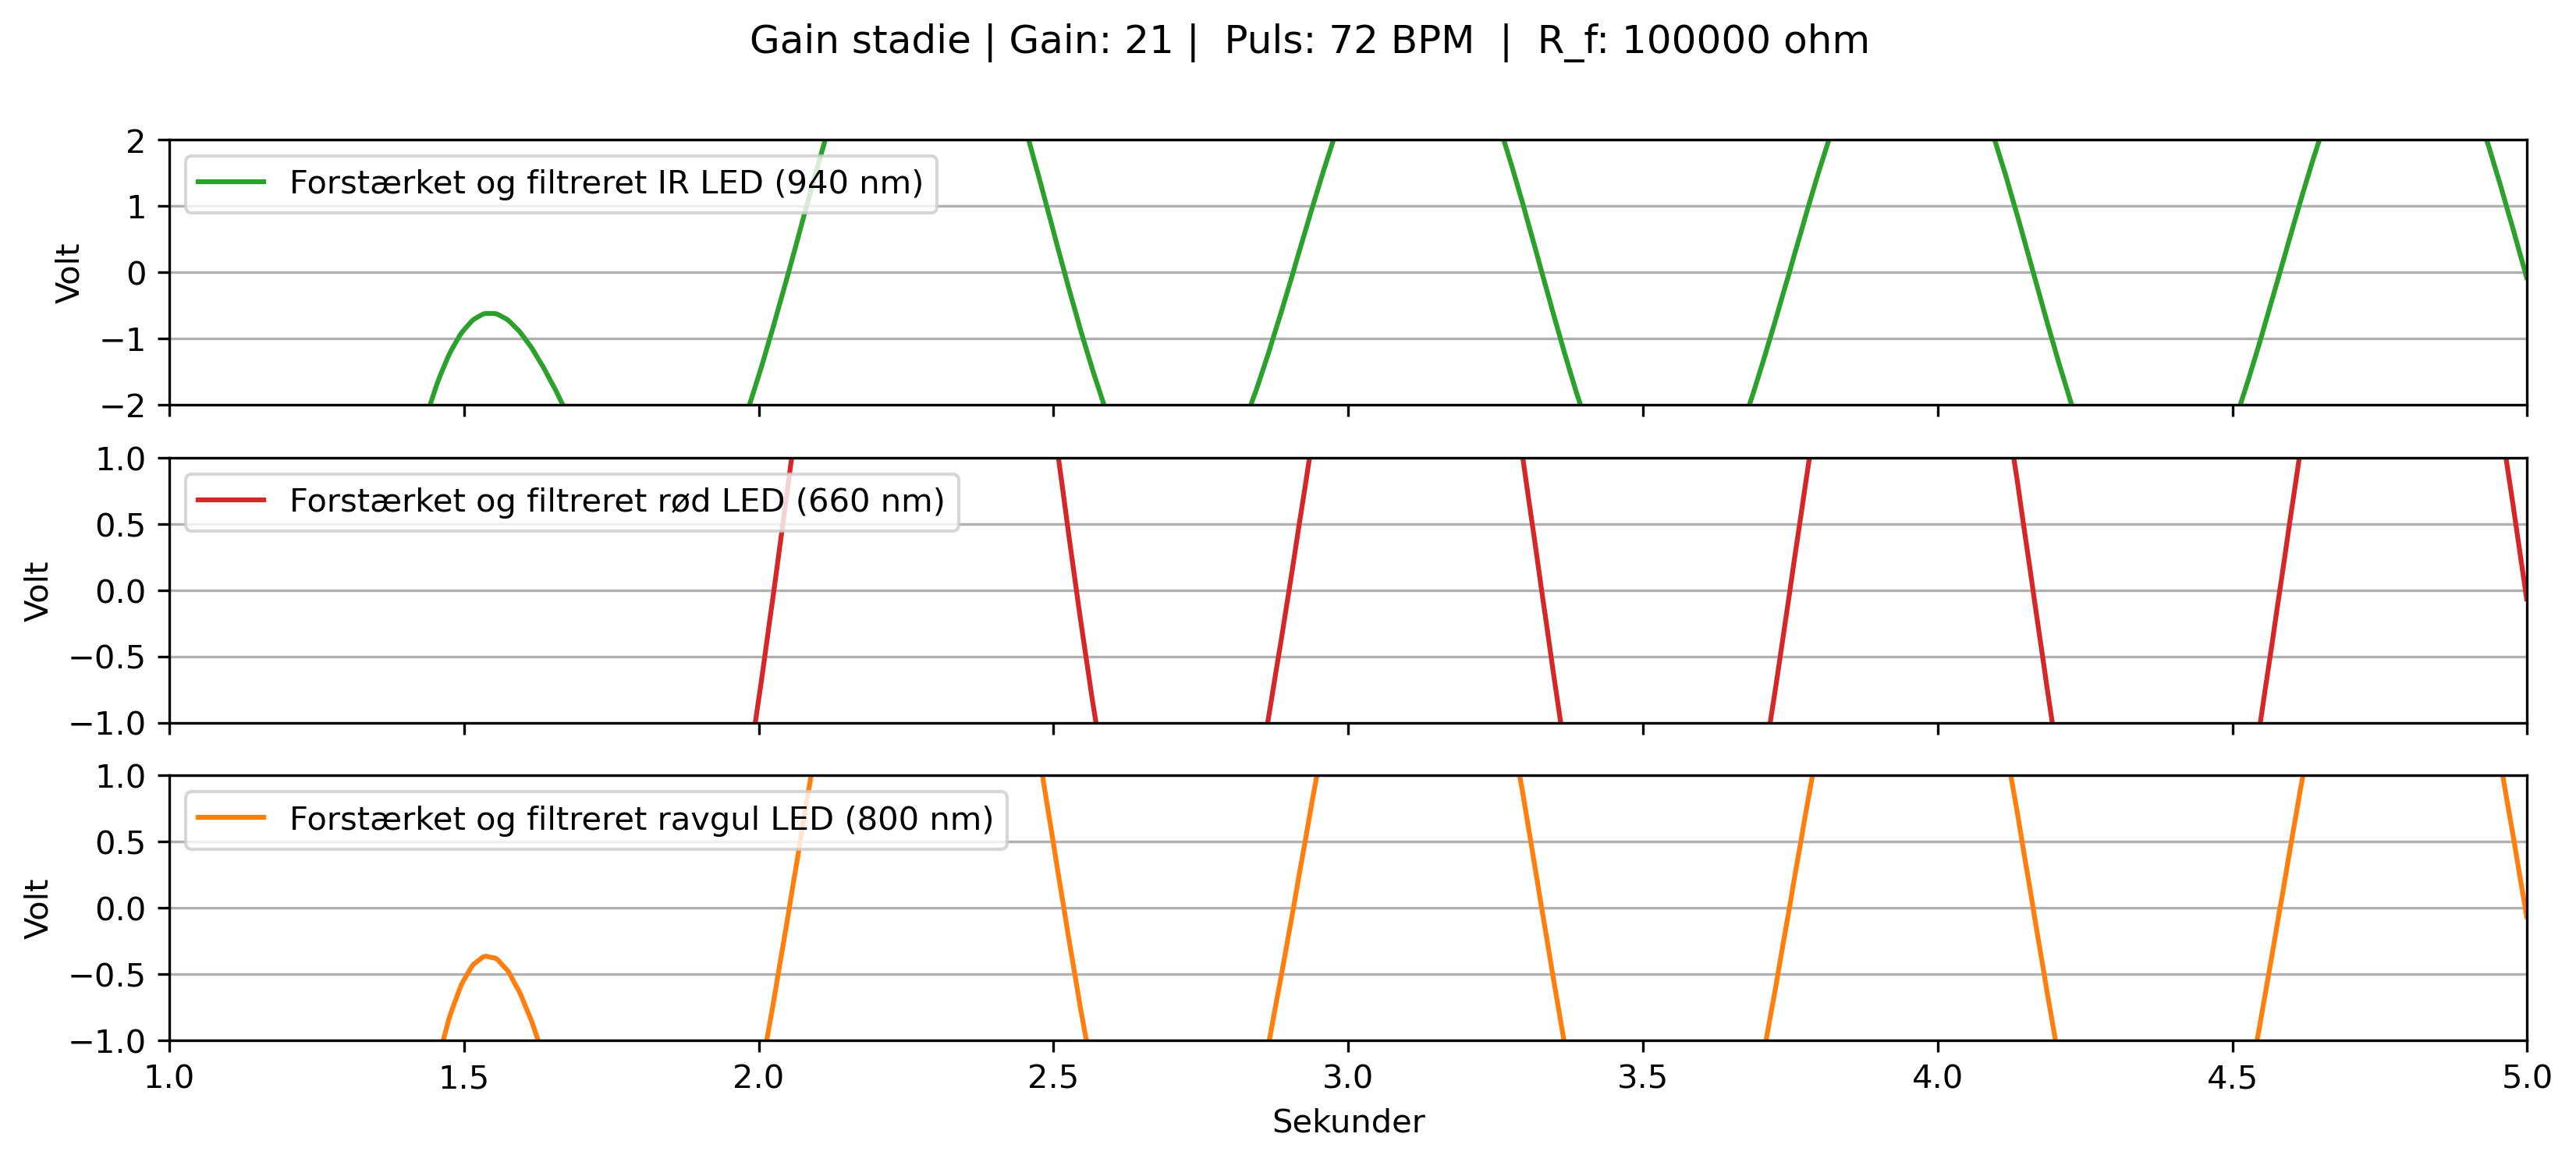

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(13, 5), dpi=300, sharex=True)
fig.suptitle(f"Gain stadie | Gain: {gain:.0f} |  Puls: {f_puls*60:.0f} BPM  |  R_f: {R_feedback} ohm")


ax[0].plot(t, V_forstærket_930, label="Forstærket og filtreret IR LED (940 nm)", color="tab:green")
ax[0].set_xlim(1, 5)
ax[0].set_ylim(-2, 2)
ax[0].set_ylabel("Volt")
ax[0].legend()
ax[0].grid(axis="y")

ax[1].plot(t, V_forstærket_660, label="Forstærket og filtreret rød LED (660 nm)", color="tab:red")
ax[1].set_xlim(1, 5)
ax[1].set_ylim(-1, 1)
ax[1].set_ylabel("Volt")
ax[1].legend()
ax[1].grid(axis="y")

ax[2].plot(t, V_forstærket_800, label="Forstærket og filtreret ravgul LED (800 nm)", color="tab:orange")
ax[2].set_xlim(1, 5)
ax[2].set_ylim(-1, 1)
ax[2].set_ylabel("Volt")
ax[2].set_xlabel("Sekunder")
ax[2].legend()
ax[2].grid(axis="y")

plt.show()

In [14]:
# Tid man venter før måler SpO2
vent = 2

# Fra det filtrerede signal (efter transient):
AC_660 = np.max(V_filt_660[vent*fs::]) - np.min(V_filt_660[vent*fs::])
AC_930 = np.max(V_filt_930[vent*fs::]) - np.min(V_filt_930[vent*fs::])

DC_660 = np.mean(V_TIA_660[vent*fs::])  # DC fra ufiltreret TIA output
DC_930 = np.mean(V_TIA_930[vent*fs::])

# Ratio of ratios
R = (AC_660 / DC_660) / (AC_930 / DC_930)

# Linear regression, Kilde: Analog Devices
SpO2 = -24.87*R + 113.8

SpO2

np.float64(99.57266016923663)

In [23]:
R_hp = 330e3
C_hp = 1e-6

R_lp = 56e3
C_lp = 1e-9

import numpy as np 
print(f"Højpas f_c: {1/(2*3.14*np.sqrt(R_hp**2 * C_hp**2))}")
print(f"Lavpas f_c: {1/(2*3.14*np.sqrt(R_lp**2 * C_lp**2))}")


Højpas f_c: 0.4825323296660876
Lavpas f_c: 2843.4940855323016


In [27]:
1/15e-9

66666666.66666667

------------


# TIA

$$
V_{out} = - I_{in} \times R_f
$$

In [ ]:
R_f = 100e3
I_in_IR = 0.055 # Udregnet fra notebook
I_in_Rød = 0.103 # Udregnet fra notebook

Vout_IR = -I_in_IR * R_f
Vout_Rød = -I_in_Rød * R_f

Vout_IR, Vout_Rød

(-5500.0, -10300.0)

# LPF

# HPF

# GAIN